# Managing AWS EC2 Servers with Boto3

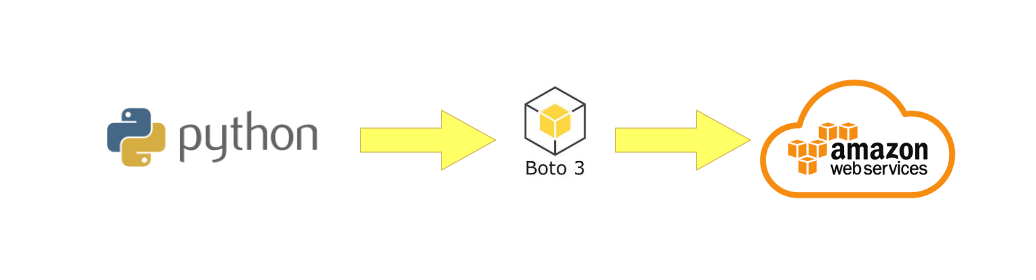

# Create Key-Pair for Secure Connection

In [14]:
import boto3

In [ ]:
ec2 = boto3.client('ec2')
ec2.describe_instances()
resp = ec2.create_key_pair(KeyName="your-keypair-name")

In [ ]:
file = open("creds/your-keypair-name", 'w')
file.write(resp['KeyMaterial'])
file.close()

# Create an Amazon EC2 Instance

In [ ]:
ec2.describe_instances()
response = ec2.run_instances(
    ImageId = "ami-xxxxxxxxxxxxxxxxx",
    MinCount=1,
    MaxCount=1,
    InstanceType = 't3.micro',
    KeyName = 'your-keypair-name',
    BlockDeviceMappings=[
        {
            "DeviceName":"/dev/xvda",
            'Ebs':{
                'DeleteOnTermination':True,
                'VolumeSize':20
            }
        }
    ]
)

In [ ]:
response

In [ ]:
ec2.describe_instances()

# Creating Security Groups and add rules to it

In [22]:
response = ec2.describe_security_groups()

In [ ]:
response = ec2.create_security_group(
    GroupName = 'your_groupName',
    Description='Security group for testing'
)

In [ ]:
security_group_id = response['GroupId']
security_group_id

In [27]:
# ip, port, traffic type

response = ec2.authorize_security_group_ingress(
    GroupId = security_group_id,
    IpPermissions=[
        {
            'IpProtocol':'tcp',
            'FromPort':22,
            'ToPort':22,
            'IpRanges':[{'CidrIp':'0.0.0.0/0'}]
        }
    ]
)

In [ ]:
response

In [41]:
response = ec2.describe_instances()

In [ ]:
response

In [45]:
instance_id = response['Reservations'][0]['Instances'][0]['InstanceId']

In [ ]:
instance_id

In [ ]:
instance_id, security_group_id

In [48]:
ec2.modify_instance_attribute(InstanceId=instance_id, Groups=[security_group_id])

{'ResponseMetadata': {'RequestId': '727561f8-1bdd-4e71-8d1b-4be6eb548e5c',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': '727561f8-1bdd-4e71-8d1b-4be6eb548e5c',
   'cache-control': 'no-cache, no-store',
   'strict-transport-security': 'max-age=31536000; includeSubDomains',
   'content-type': 'text/xml;charset=UTF-8',
   'content-length': '235',
   'date': 'Tue, 21 Jul 2026 12:49:51 GMT',
   'server': 'AmazonEC2'},
  'RetryAttempts': 0}}

In [49]:
response['Reservations'][0]['Instances'][0]['State']

{'Code': 16, 'Name': 'running'}

# Start, Stop and Delete Amazon EC2 Instances

## Starting the Instances

In [53]:
import time

def wait_for_status(instance_ids, target_status):
    while True:
        response = ec2.describe_instances(InstanceIds=instance_ids)

        status = response['Reservations'][0]['Instances'][0]['State']['Name']

        print("Current Status:", status)

        if status == target_status:
            print(f"Instance is in {target_status} state")
            break

        time.sleep(10)


def start_instances(instance_ids):
    print("EC2 Instance Start")

    ec2.start_instances(InstanceIds=instance_ids)

    wait_for_status(instance_ids, "running")


start_instances([instance_id])

EC2 Instance Start
Current Status: running
Instance is in running state


## Stopping the Instances

In [55]:
def stop_instances(instance_ids):
    print("EC2 Instance Stop")

    ec2.stop_instances(InstanceIds=instance_ids)

    wait_for_status(instance_ids, "stopped")

stop_instances([instance_id])

EC2 Instance Stop
Current Status: running
Current Status: stopping
Current Status: stopped
Instance is in stopped state


## Terminating the Instances

In [57]:
def terminate_instances(instance_ids):
    print("EC2 Instance Terminated")

    ec2.terminate_instances(InstanceIds=instance_ids)

    wait_for_status(instance_ids, "terminated")

terminate_instances([instance_id])

EC2 Instance Terminated
Current Status: terminated
Instance is in terminated state
